In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

df = pd.read_csv('../data/raw/air_quality.csv')
print("Loaded!", df.shape)

Loaded! (29531, 16)


In [2]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene', 
                  'Toluene', 'Xylene']

# Before
missing_before = df[pollutant_cols].isnull().sum()

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
df[pollutant_cols] = imputer.fit_transform(df[pollutant_cols])

# After
missing_after = df[pollutant_cols].isnull().sum()

print("Missing BEFORE:\n", missing_before)
print("\nMissing AFTER:\n", missing_after)

Missing BEFORE:
 PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
dtype: int64

Missing AFTER:
 PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


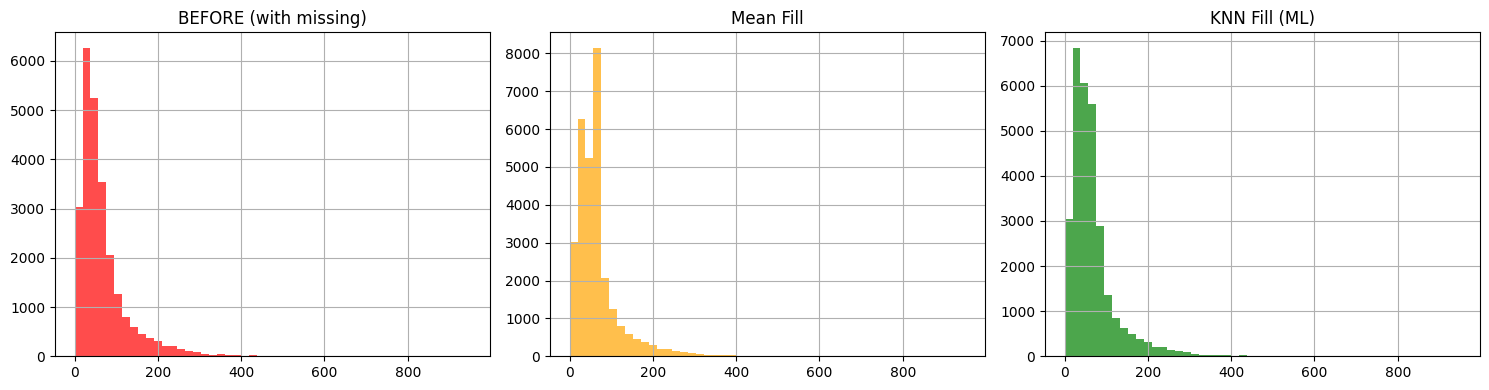

✅ Plot saved!


In [3]:
# Reload original to compare
df_original = pd.read_csv('../data/raw/air_quality.csv')

# Mean fill
df_mean = df_original.copy()
df_mean['PM2.5'] = df_mean['PM2.5'].fillna(df_mean['PM2.5'].mean())

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_original['PM2.5'].hist(bins=50, ax=axes[0], color='red', alpha=0.7)
axes[0].set_title('BEFORE (with missing)')

df_mean['PM2.5'].hist(bins=50, ax=axes[1], color='orange', alpha=0.7)
axes[1].set_title('Mean Fill')

df['PM2.5'].hist(bins=50, ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('KNN Fill (ML)')

plt.tight_layout()
plt.savefig('../reports/before_plots/pm25_imputation_comparison.png')
plt.show()
print("✅ Plot saved!")

In [4]:
df.to_csv('../data/processed/step1_missing_fixed.csv', index=False)
print("✅ Saved to data/processed/step1_missing_fixed.csv")

✅ Saved to data/processed/step1_missing_fixed.csv


In [5]:
df = pd.read_csv('../data/processed/step1_missing_fixed.csv')
print("Loaded cleaned data!", df.shape)

Loaded cleaned data! (29531, 16)


In [6]:
def fix_outliers(df, col, strategy='cap'):
    if strategy == 'cap':
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower=lower, upper=upper)
    elif strategy == 'remove':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    return df

print("✅ fix_outliers function ready!")

✅ fix_outliers function ready!


In [7]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene', 
                  'Toluene', 'Xylene']

df_fixed = df.copy()

for col in pollutant_cols:
    df_fixed = fix_outliers(df_fixed, col, strategy='cap')

print("✅ Outliers capped for all pollutant columns!")
print("Row count before:", len(df))
print("Row count after :", len(df_fixed))

✅ Outliers capped for all pollutant columns!
Row count before: 29531
Row count after : 29531


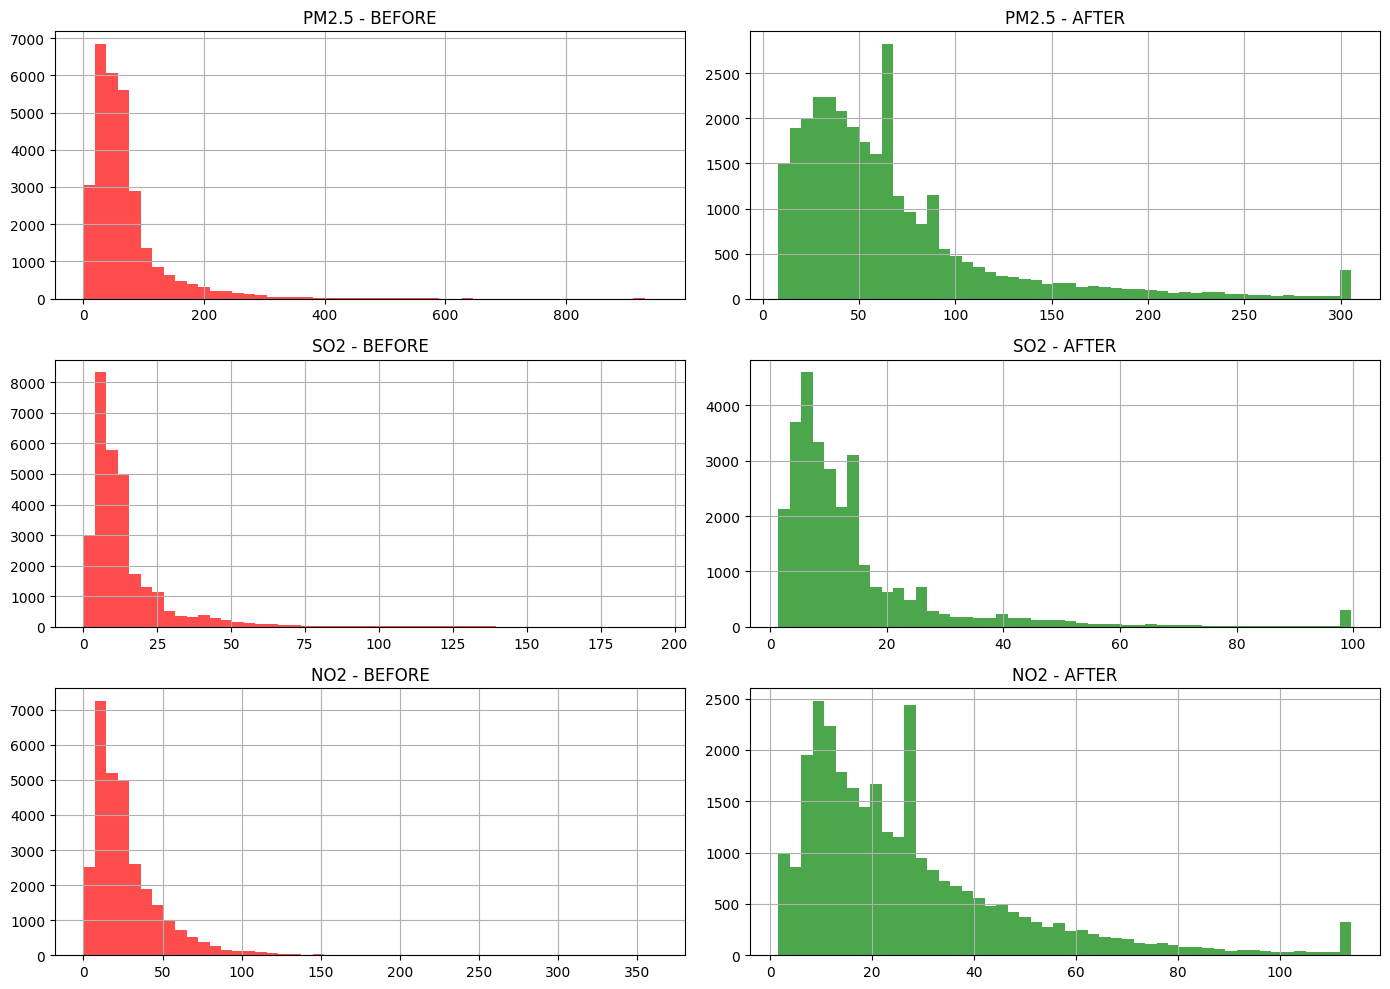

✅ Plot saved!


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(['PM2.5', 'SO2', 'NO2']):
    df[col].hist(bins=50, ax=axes[i][0], color='red', alpha=0.7)
    axes[i][0].set_title(f'{col} - BEFORE')
    
    df_fixed[col].hist(bins=50, ax=axes[i][1], color='green', alpha=0.7)
    axes[i][1].set_title(f'{col} - AFTER')

plt.tight_layout()
plt.savefig('../reports/before_plots/outliers_before_after.png')
plt.show()
print("✅ Plot saved!")

In [9]:
df_fixed.to_csv('../data/processed/step2_outliers_fixed.csv', index=False)
print("✅ Saved to data/processed/step2_outliers_fixed.csv")

✅ Saved to data/processed/step2_outliers_fixed.csv


In [10]:
df = pd.read_csv('../data/processed/step2_outliers_fixed.csv')
print("Loaded!", df.shape)

Loaded! (29531, 16)


In [11]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicates removed: 0
Rows remaining: 29531


In [12]:
df['City'] = df['City'].str.strip().str.title()
print("✅ City names standardized!")
print(df['City'].unique())

✅ City names standardized!
<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str


In [13]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print("✅ Date column fixed!")
print("Date dtype:", df['Date'].dtype)
print("Unparseable dates:", df['Date'].isnull().sum())

✅ Date column fixed!
Date dtype: datetime64[us]
Unparseable dates: 0


In [14]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene', 
                  'Toluene', 'Xylene']

df[pollutant_cols] = df[pollutant_cols].astype(float)
print("✅ All pollutant columns cast to float64!")
print(df[pollutant_cols].dtypes)

✅ All pollutant columns cast to float64!
PM2.5      float64
PM10       float64
NO         float64
NO2        float64
NOx        float64
NH3        float64
CO         float64
SO2        float64
O3         float64
Benzene    float64
Toluene    float64
Xylene     float64
dtype: object
